<a href="https://www.kaggle.com/code/kaushikfreddyregalla/04-transfer-learning-mobilenetv2-vgg16?scriptVersionId=325245952" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 04 — Transfer Learning (MobileNetV2 & VGG16)
Hand Gesture Recognition | Kaushik Reddy Ragalla

In [1]:
import os, types, sys, io, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
_stderr = sys.stderr; sys.stderr = io.StringIO()
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
sys.stderr = _stderr

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
NUM_CLASSES = 10
BATCH_SIZE  = 32
os.makedirs('figures', exist_ok=True)

# ── Find and load .npy files ─────────────────────────────────────────────────
NPY_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'X_train.npy' in files:
        NPY_DIR = root; break
if NPY_DIR is None and os.path.exists('/kaggle/working/X_train.npy'):
    NPY_DIR = '/kaggle/working'
assert NPY_DIR, 'X_train.npy not found! Attach notebook 02 output as input.'
print(f'Loading from: {NPY_DIR}')

X_train = np.load(f'{NPY_DIR}/X_train.npy')
y_train = np.load(f'{NPY_DIR}/y_train.npy')
X_val   = np.load(f'{NPY_DIR}/X_val.npy')
y_val   = np.load(f'{NPY_DIR}/y_val.npy')
X_test  = np.load(f'{NPY_DIR}/X_test.npy')
y_test  = np.load(f'{NPY_DIR}/y_test.npy')
print(f'Loaded — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')


E0000 00:00:1780861479.561824      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780861479.622736      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780861480.083548      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780861480.083583      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780861480.083585      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780861480.083588      23 computation_placer.cc:177] computation placer already registered. Please check linka

Loading from: /kaggle/input/notebooks/kaushikfreddyregalla/02-preprocessing-data-augmentation
Loaded — Train: (14000, 128, 128, 1), Val: (3000, 128, 128, 1), Test: (3000, 128, 128, 1)


In [2]:
# ── Convert grayscale (N,128,128,1) → RGB (N,128,128,3) ─────────────────────
# MobileNetV2 and VGG16 expect 3-channel input

def gray_to_rgb(X):
    return np.repeat(X, 3, axis=-1)

X_train_rgb = gray_to_rgb(X_train)
X_val_rgb   = gray_to_rgb(X_val)
X_test_rgb  = gray_to_rgb(X_test)
print(f'RGB shape: {X_train_rgb.shape}')

# Augmentation generators for RGB
train_datagen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
val_datagen = ImageDataGenerator()

train_gen_rgb = train_datagen.flow(X_train_rgb, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen_rgb   = val_datagen.flow(X_val_rgb,     y_val,   batch_size=BATCH_SIZE, shuffle=False)

RGB shape: (14000, 128, 128, 3)


In [3]:
# ── Helper: plot training curves ─────────────────────────────────────────────
def plot_curves(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    ax1.plot(history.history['accuracy'],     label='Train',      color='steelblue', lw=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', color='orangered', lw=2)
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history.history['loss'],     label='Train',      color='steelblue', lw=2)
    ax2.plot(history.history['val_loss'], label='Validation', color='orangered', lw=2)
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')

In [4]:
# ── MobileNetV2 — Build model ────────────────────────────────────────────────

base_mob = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_mob.trainable = False  # freeze base for Phase 1

inp = layers.Input(shape=(128,128,3))
x = layers.Rescaling(scale=2.0, offset=-1.0)(inp)  # scale [0,1] → [-1,1] for MobileNetV2
x = base_mob(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = models.Model(inputs=inp, outputs=out, name='MobileNetV2_TL')
mobilenet_model.summary()

I0000 00:00:1780861504.370916      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780861504.376765      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# ── MobileNetV2 — Phase 1: Train head only (base frozen) ────────────────────
mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

tl_cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_mobilenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

steps = len(X_train_rgb) // BATCH_SIZE
tl_history = mobilenet_model.fit(
    train_gen_rgb, steps_per_epoch=steps, epochs=20,
    validation_data=val_gen_rgb, callbacks=tl_cb, verbose=1)
print('Phase 1 complete.')

Epoch 1/20


I0000 00:00:1780861511.628803      68 service.cc:152] XLA service 0x793928041560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780861511.628856      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780861511.628863      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780861512.690281      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780861523.490176      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8774 - loss: 0.3791
Epoch 1: val_accuracy improved from None to 0.99133, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 93s 172ms/step - accuracy: 0.9508 - loss: 0.1501 - val_accuracy: 0.9913 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 2/20
  1/437 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 1.0000 - loss: 0.0133
Epoch 2: val_accuracy improved from 0.99133 to 0.99200, saving model to best_mobilenet.keras

Epoch 2: finished saving model to best_mobilenet.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.9920 - val_loss: 0.0222 - learning_rate: 0.0010
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9883 - loss: 0.0335
Epoch 3: val_accuracy improved from 0.99200 to 0.99700, saving model to best_mobilenet.keras

Epoch 3: finished saving model to best_mobilenet.keras
437/437 ━━━━━━━━━━━

Epoch 1/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8973 - loss: 0.3745
Epoch 1: val_accuracy did not improve from 0.99967
437/437 ━━━━━━━━━━━━━━━━━━━━ 77s 142ms/step - accuracy: 0.9461 - loss: 0.1822 - val_accuracy: 0.9933 - val_loss: 0.0296 - learning_rate: 1.0000e-05
Epoch 2/10
  1/437 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 1.0000 - loss: 0.0244
Epoch 2: val_accuracy did not improve from 0.99967
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.9933 - val_loss: 0.0295 - learning_rate: 1.0000e-05
Epoch 3/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9839 - loss: 0.0497
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.99967
437/437 ━━━━━━━━━━━━━━━━━━━━ 49s 113ms/step - accuracy: 0.9860 - loss: 0.0441 - val_accuracy: 0.9953 - val_loss: 0.0160 - learning_rate: 1.0000e-05
Epoch 4/10
  1/437 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 

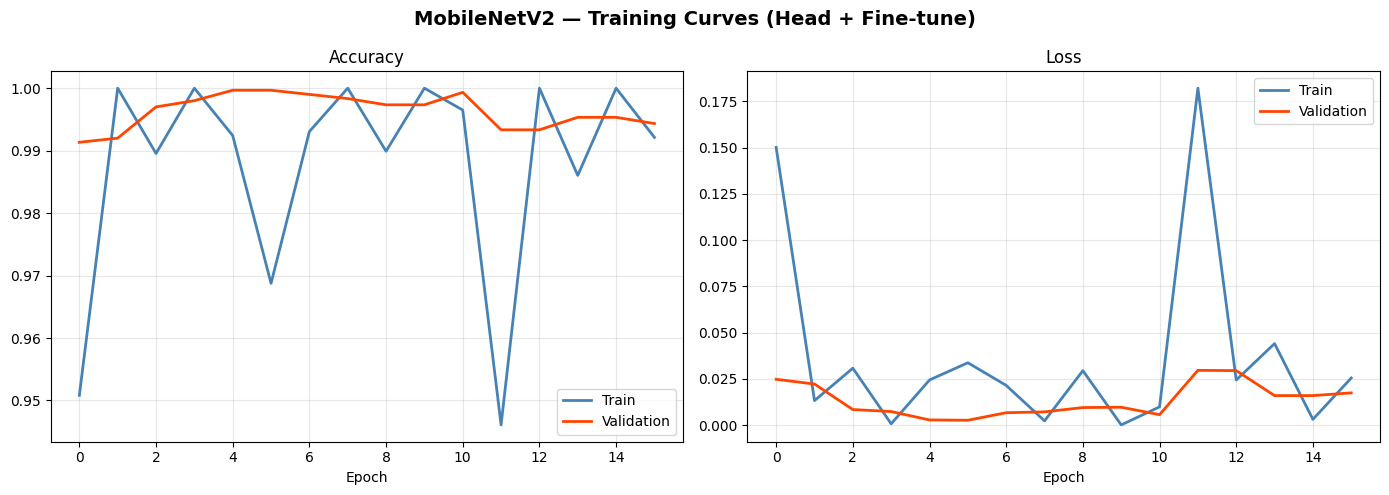

Saved: figures/training_curves_mobilenet.png


In [6]:
# ── MobileNetV2 — Phase 2: Fine-tune top 30 layers ───────────────────────────
base_mob.trainable = True
for layer in base_mob.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-5),  # very low LR for fine-tuning
    loss='categorical_crossentropy', metrics=['accuracy'])

ft_history = mobilenet_model.fit(
    train_gen_rgb, steps_per_epoch=steps, epochs=10,
    validation_data=val_gen_rgb, callbacks=tl_cb, verbose=1)
print('Fine-tuning complete.')

# Combine histories for one clean plot
combined_mob = types.SimpleNamespace()
combined_mob.history = {k: tl_history.history[k] + ft_history.history[k] for k in tl_history.history}

plot_curves(combined_mob,
            'MobileNetV2 — Training Curves (Head + Fine-tune)',
            'figures/training_curves_mobilenet.png')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5969 - loss: 1.3981
Epoch 1: val_accuracy improved from None to 0.97800, saving model to best_vgg16.keras

Epoch 1: finished saving model to best_vgg16.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 76s 156ms/step - accuracy: 0.7825 - loss: 0.8539 - val_accuracy: 0.9780 - val_loss: 0.1788 - learning_rate: 0.0010
Epoch 2/20
  1/437 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9062 - loss: 0.3708
Epoch 2: val_accuracy did not improve from 0.97800
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9062 - loss: 0.3708 - val_accuracy: 0.9767 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9384 - loss: 0.2603
Epoch 3: val_accuracy improved from 0.97800 to 0.99167, saving model to best_vgg16.keras

Epoch 3: finished saving model to best_vgg16.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 55s 127ms/step - accuracy: 0.9501 - loss

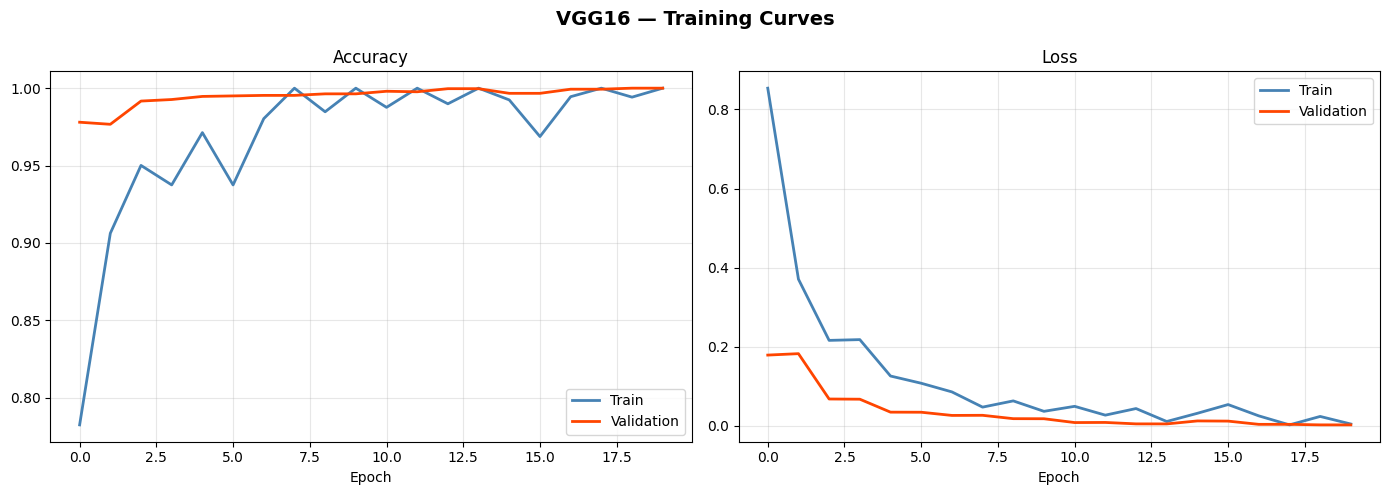

Saved: figures/training_curves_vgg16.png
Models saved.


In [7]:
# ── VGG16 — Build and train ──────────────────────────────────────────────────
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_vgg.trainable = False

inp = layers.Input(shape=(128,128,3))
x = base_vgg(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = models.Model(inputs=inp, outputs=out, name='VGG16_TL')
vgg_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

vgg_cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint('best_vgg16.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

vgg_history = vgg_model.fit(
    train_gen_rgb, steps_per_epoch=steps, epochs=20,
    validation_data=val_gen_rgb, callbacks=vgg_cb, verbose=1)

plot_curves(vgg_history, 'VGG16 — Training Curves', 'figures/training_curves_vgg16.png')

# Save models
mobilenet_model.save('best_mobilenet_final.keras')
vgg_model.save('best_vgg16_final.keras')
print('Models saved.')